## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [23]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import torch
import pickle

sys.path.insert(0, "../../../Mamoth")
sys.path.insert(0, "../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [6]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [7]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [8]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

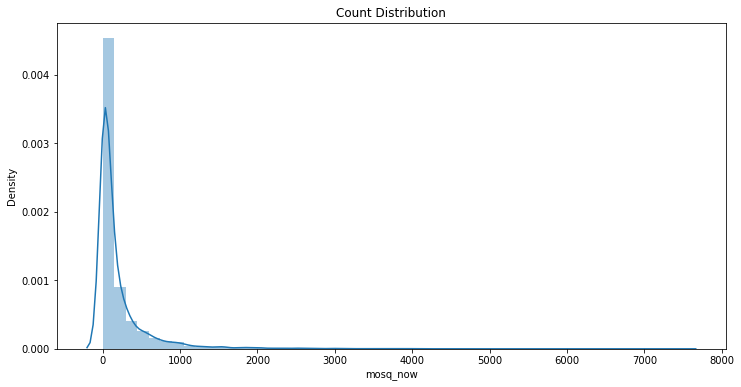

In [9]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [10]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

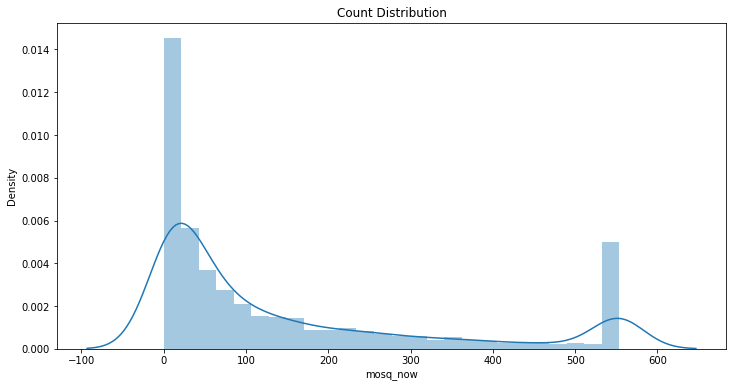

In [11]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

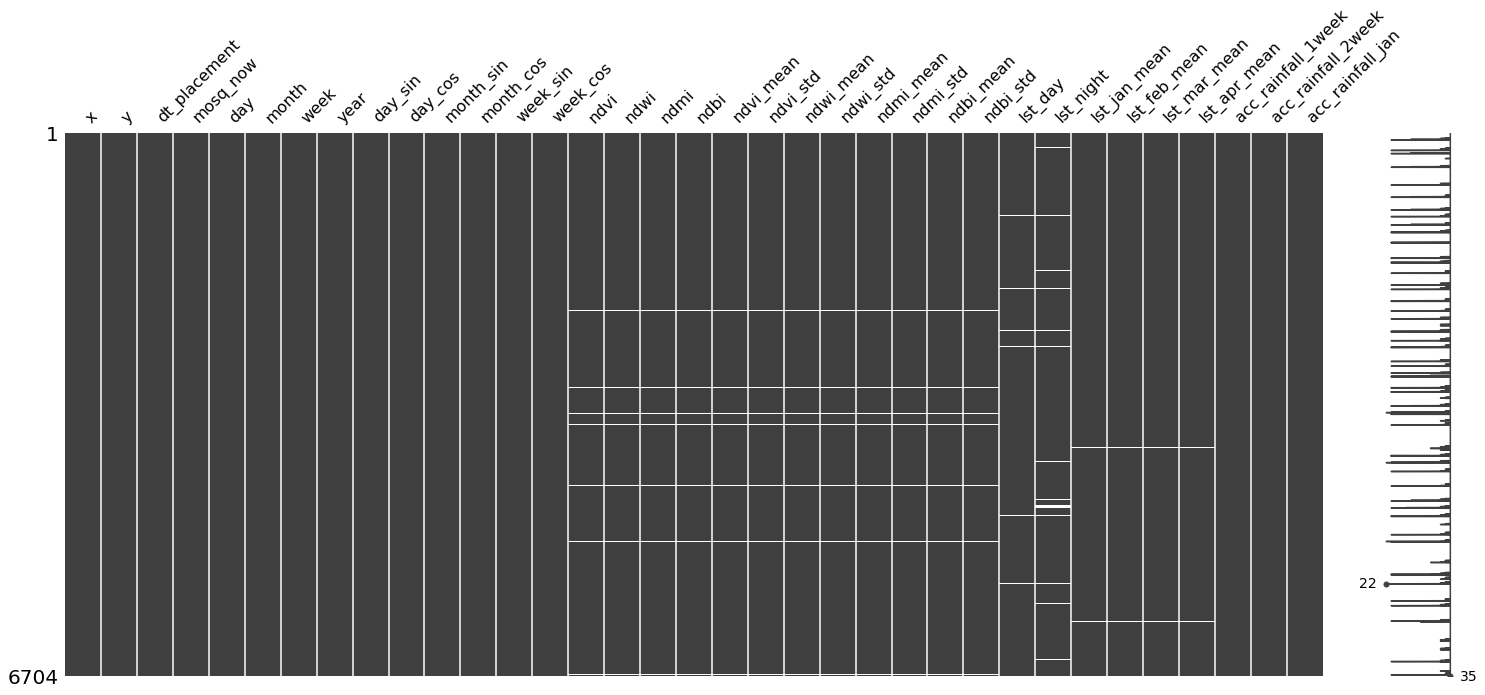

In [12]:
missingno.matrix(mosquito_data_nuts2)

In [13]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [14]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

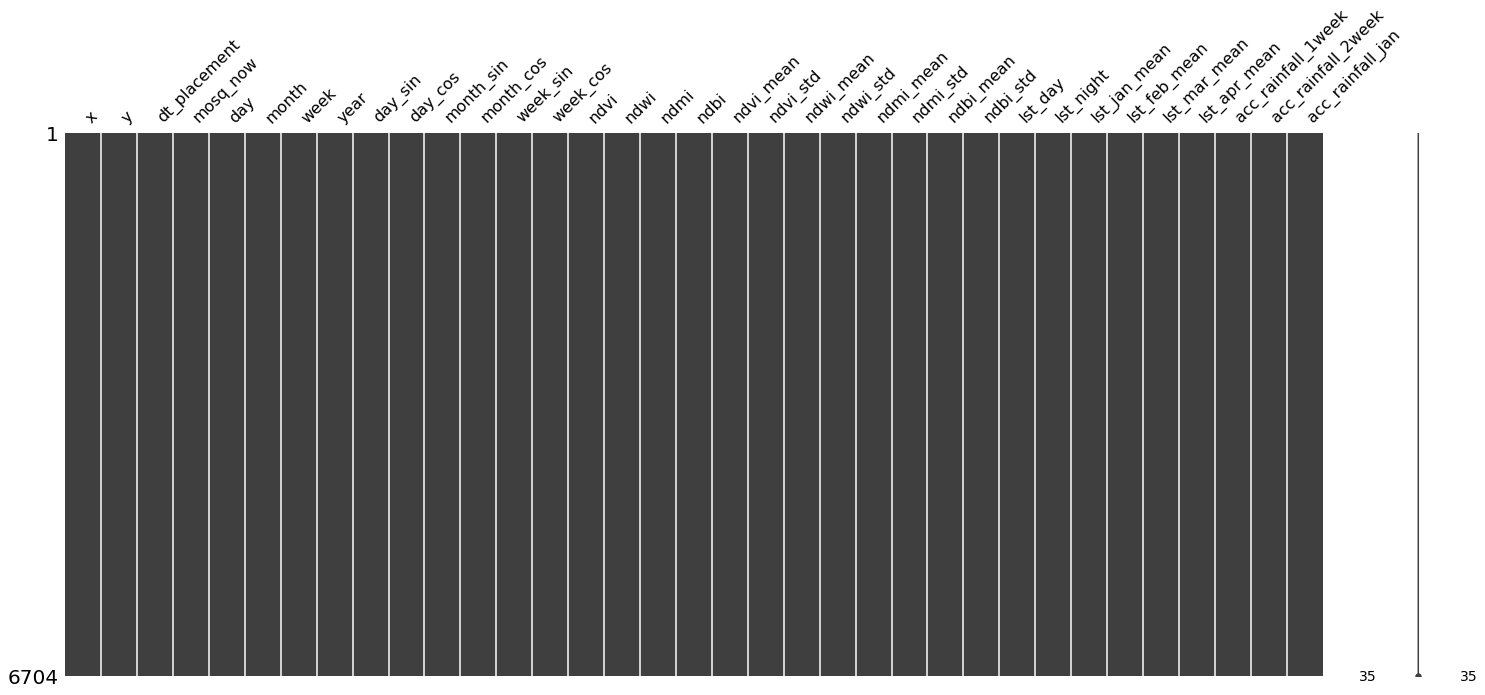

In [15]:
missingno.matrix(mosquito_data_nuts2)

In [16]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [17]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [18]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 7.48337 | Val Loss: 6.63650 | Train Acc: 1.963| Val Acc: 1.661
Epoch 002: | Train Loss: 6.22660 | Val Loss: 4.87777 | Train Acc: 1.671| Val Acc: 1.414
Epoch 003: | Train Loss: 5.55866 | Val Loss: 3.98249 | Train Acc: 1.547| Val Acc: 1.116
Epoch 004: | Train Loss: 5.63621 | Val Loss: 3.98531 | Train Acc: 1.558| Val Acc: 1.150
Epoch 005: | Train Loss: 5.23176 | Val Loss: 4.27901 | Train Acc: 1.479| Val Acc: 1.173
Epoch 006: | Train Loss: 5.25786 | Val Loss: 4.28830 | Train Acc: 1.474| Val Acc: 1.235
Epoch 007: | Train Loss: 5.02737 | Val Loss: 4.22671 | Train Acc: 1.443| Val Acc: 1.216
Epoch 008: | Train Loss: 4.89080 | Val Loss: 4.19192 | Train Acc: 1.413| Val Acc: 1.171
Epoch 009: | Train Loss: 4.85676 | Val Loss: 4.08868 | Train Acc: 1.394| Val Acc: 1.163
Epoch 010: | Train Loss: 4.58008 | Val Loss: 3.93954 | Train Acc: 1.349| Val Acc: 1.124
Epoch 011: | Train Loss: 4.68203 | Val Loss: 4.15045 | Train Acc: 1.366| Val Acc: 1.183
Epoch 012: | Train Loss: 4.70008

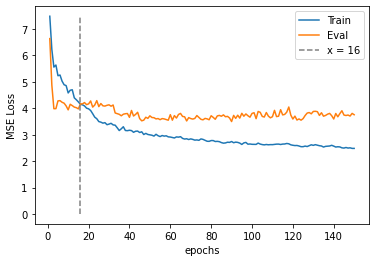

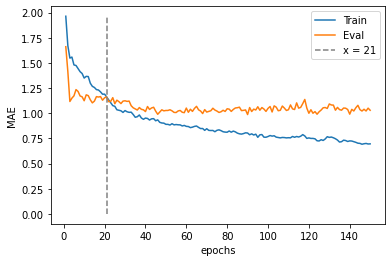

In [19]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [20]:
metrics(train, test, threshold=30)

MAE on train set:  87.0201094472637
min prediction: 1
max prediction: 833

MAE on test set:  89.85455016603875
Error ⩽ 30: 34.88 %
min prediction: 1
max prediction: 822


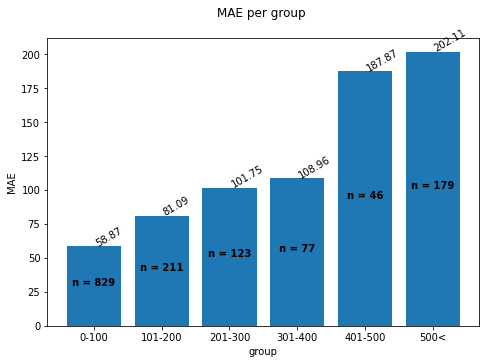

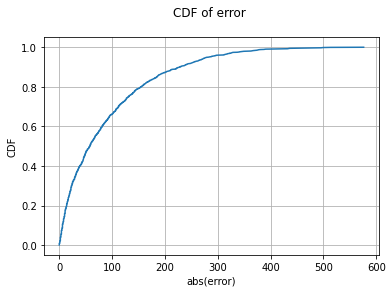

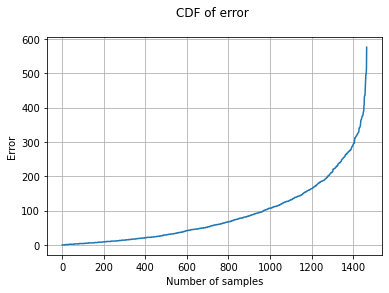

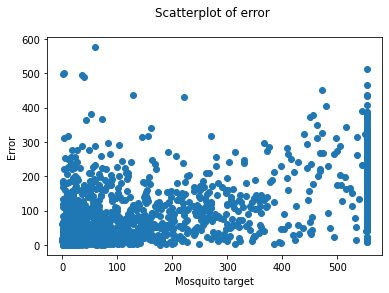

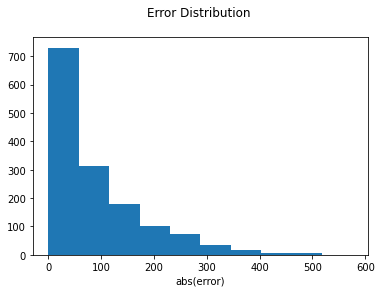

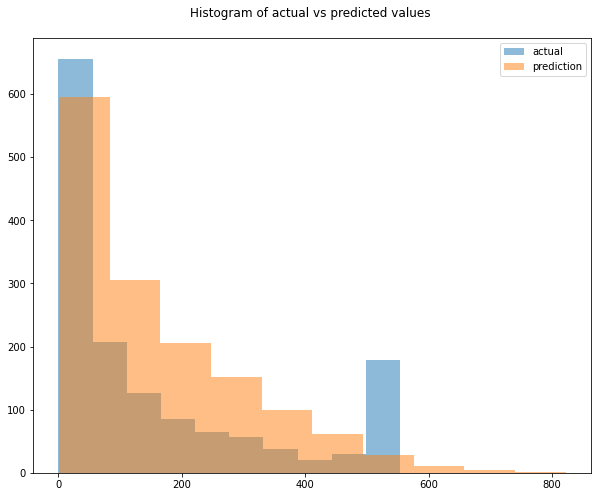

In [21]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.84760 | Val Loss: 0.00002 | Train Acc: 0.860| Val Acc: 0.394
Epoch 002: | Train Loss: 2.80584 | Val Loss: 0.07583 | Train Acc: 0.862| Val Acc: 0.606
Epoch 003: | Train Loss: 2.73035 | Val Loss: 0.07570 | Train Acc: 0.841| Val Acc: 0.606
Epoch 004: | Train Loss: 2.73081 | Val Loss: 0.05660 | Train Acc: 0.852| Val Acc: 0.394
Epoch 005: | Train Loss: 2.67920 | Val Loss: 0.00700 | Train Acc: 0.834| Val Acc: 0.394
Epoch 006: | Train Loss: 2.68608 | Val Loss: 0.11047 | Train Acc: 0.833| Val Acc: 0.394
Epoch 007: | Train Loss: 2.70698 | Val Loss: 0.22234 | Train Acc: 0.843| Val Acc: 0.394
Epoch 008: | Train Loss: 2.64941 | Val Loss: 0.13741 | Train Acc: 0.818| Val Acc: 0.394
Epoch 009: | Train Loss: 2.66132 | Val Loss: 0.56421 | Train Acc: 0.815| Val Acc: 0.394
Epoch 010: | Train Loss: 2.58515 | Val Loss: 0.78698 | Train Acc: 0.802| Val Acc: 0.394
Epoch 011: | Train Loss: 2.59482 | Val Loss: 0.48932 | Train Acc: 0.795| Val Acc: 0.394
Epoch 012: | Train Loss: 2.53759

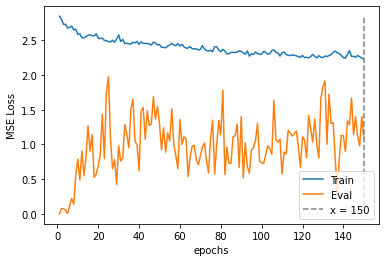

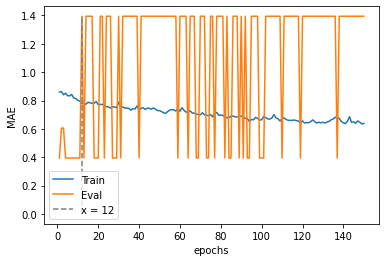

In [22]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [24]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'wb'))